In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.losses import Huber
from tensorflow.keras.layers import LSTM
import tensorflow as tf
from sklearn.model_selection import TimeSeriesSplit


In [2]:
TEST_RATIO = 0.1
TOP_N = 20
SEED = 42
WINDOW_SIZE = 10
TOMORROW_SHIFT = -1
DATA_BASE_PATH = Path("./data")

In [3]:
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
tf.config.experimental.enable_op_determinism()

In [5]:
gold_file_path = DATA_BASE_PATH / "final_gold_data.csv"

In [6]:
gold = pd.read_csv(gold_file_path, sep=";", encoding="utf-8", parse_dates=["timestamp"])
price_cols = ["high", "low", "open", "close"]
gold.head()

,timestamp,open,high,low,close,volume,currency,unit,headlines
0,2000-08-30,273.9,273.9,273.9,273.9,0,usd,ounce,Recalls Fuel Disclosure Debate / Deutsche Tele...
1,2000-08-31,274.8,278.3,274.8,278.3,0,usd,ounce,Credit Suisse's Wheat Faces Deal / Regulators ...
2,2000-09-01,277.0,277.0,277.0,277.0,0,usd,ounce,Nordstrom's Chief Resigns / Judge Dismisses Ca...
3,2000-09-05,275.8,275.8,275.8,275.8,2,usd,ounce,Market Pace Slows After 10-Year Run / Clickman...
4,2000-09-06,274.2,274.2,274.2,274.2,0,usd,ounce,France Telecom Profit Increases / Locale-Based...


In [7]:
gold["day_variation"] = gold["open"] - gold["close"]
gold["max_diff"] = gold["high"] - gold["low"]

In [8]:
# pca = PCA(n_components=1)
# gold["price_pca"] = pca.fit_transform(gold[["high", "low", "open", "close"]])

In [9]:
gold["tomorrow_close"] = gold["close"].shift(TOMORROW_SHIFT)
gold = gold.dropna(subset=["tomorrow_close"])  # Remove last row with NaN

In [10]:
gold["target_return"] = (
    gold["tomorrow_close"] - gold["close"]
) / gold["close"]

In [11]:
gold["day_of_week"] = gold["timestamp"].dt.dayofweek
gold["month"] = gold["timestamp"].dt.month

In [12]:
delta = gold["close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

gold["rsi_14"] = 100 - (100 / (1 + rs))

In [13]:
gold = gold.dropna()

In [14]:
TARGET = "target_return"

to_drop = [
    "currency",
    "unit",
    "timestamp",
    "headlines",
    "tomorrow_close",
]

X = gold.drop(columns=to_drop + [TARGET])

y = gold[TARGET]

In [15]:
n_features = X.shape[1]

In [16]:
model = Sequential()

model.add(
    Conv1D(
        filters=32,
        kernel_size=3,
        activation="relu",
        input_shape=(WINDOW_SIZE, n_features)
    )
)

model.add(MaxPooling1D(pool_size=2))

model.add(LSTM(32))

model.add(Dropout(0.2))

model.add(Dense(16, activation='relu'))

model.add(Dense(1))

model.compile(optimizer=Adam(learning_rate=0.001), loss=Huber())

c:\Users\fpaul\Documents\GitHub\machine-learning-works\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
param_grid = {
    "filters": [16, 32],
    "lstm_units": [32, 64],
    "learning_rate": [0.001, 0.0005]
}

In [18]:
def create_sequences(X, y, window_size):

    Xs = []
    ys = []

    for i in range(len(X) - window_size):

        Xs.append(X[i:i + window_size])

        ys.append(y.iloc[i + window_size])

    return np.array(Xs), np.array(ys)

In [19]:
X_seq, y_seq = create_sequences(
    X.to_numpy(),
    y,
    WINDOW_SIZE
)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=TEST_RATIO,
    shuffle=False,
    random_state=42
)

In [21]:
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, n_features)
X_test_2d = X_test.reshape(-1, n_features)

X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled = scaler.transform(X_test_2d)

X_train_scaled = X_train_scaled.reshape(X_train.shape)
X_test_scaled = X_test_scaled.reshape(X_test.shape)

In [22]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    min_delta=1e-6,
    restore_best_weights=True
)

In [23]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=False
)

Epoch 1/100


156/156 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0042 - val_loss: 8.3280e-05
Epoch 2/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.3637e-04 - val_loss: 6.1193e-05
Epoch 3/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.9969e-04 - val_loss: 5.6698e-05
Epoch 4/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.3965e-04 - val_loss: 5.4052e-05
Epoch 5/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.1207e-04 - val_loss: 5.1545e-05
Epoch 6/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.5741e-05 - val_loss: 5.0512e-05
Epoch 7/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.4667e-05 - val_loss: 4.9168e-05
Epoch 8/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.7875e-05 - val_loss: 4.8551e-05
Epoch 9/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.8904e-05 - val_loss: 4.8282e-05
Epoch 10/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.1640e-05 - val_loss: 4.8102e-05
Epoch 11/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 6

In [24]:
y_pred = model.predict(X_test_scaled)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


In [25]:
rmse = root_mean_squared_error(y_test, y_pred)

print("RMSE:", rmse)

RMSE: 0.009328590586248856


In [26]:
rme_train = root_mean_squared_error(
    y_train,
    model.predict(X_train_scaled)
)

rme_test = root_mean_squared_error(
    y_test,
    model.predict(X_test_scaled)
)

  1/173 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step

173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [27]:
rme_train, rme_test

(0.011108093154512905, 0.009328590586248856)

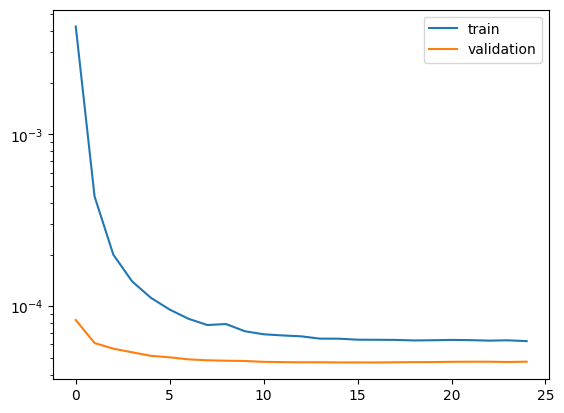

In [28]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')

plt.yscale('log')

plt.legend()
plt.show()

In [29]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

direction_acc = np.mean(
    np.sign(y_pred.flatten()) == np.sign(y_test)
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("Direction Accuracy:", direction_acc)

MAE: 0.0070053060190192725
RMSE: 0.009328590586248856
R2: -0.012788778275621748
Direction Accuracy: 0.560064935064935
